# PART 1

In [1]:
# Standard imports
import numpy as np

# Utils
from config import *
from utils.segment import *
from utils.display import loadAndDisplay, getSlice
from utils.filtering import *

from IPython.display import display

In [2]:
# In this part theese are all the data we need
t1_dict   = loadAndDisplay(T1_PATH, "T1-WEIGHTED", print_summary=False)
mask_dict = loadAndDisplay(MASK_PATH, 'MASK', print_summary=False)
fmri_dict = loadAndDisplay(FMRI_PATH, "FMRI", print_summary=False)

## T1-Brain extraction
Here I want to put to zero every value that is outside the valid points of the mask --> np.where is the best function to use, and we can apply it by using a boolean mask

In [13]:
bool_mask = mask_dict['data'].astype(bool)
t1_brain = np.where(bool_mask, t1_dict['data'], 0) # np.where keep the same dimension of the starting array.
np.save('data/part1/t1_brain.npy', t1_brain)

## Tissue Segmentation
In these cells I will perform tissue segmentation, trying different methods and comparing them. Most of the library methods that implement segmentation techniques require the input data to be in the form
of (samples, features), so the first thing I need to do is to vectorize my data.
These are some of the methods I'm implementing:
- K-Mean
- Multithreshold Otsu
- Simple Thresholding
- Adaptive Thresholding

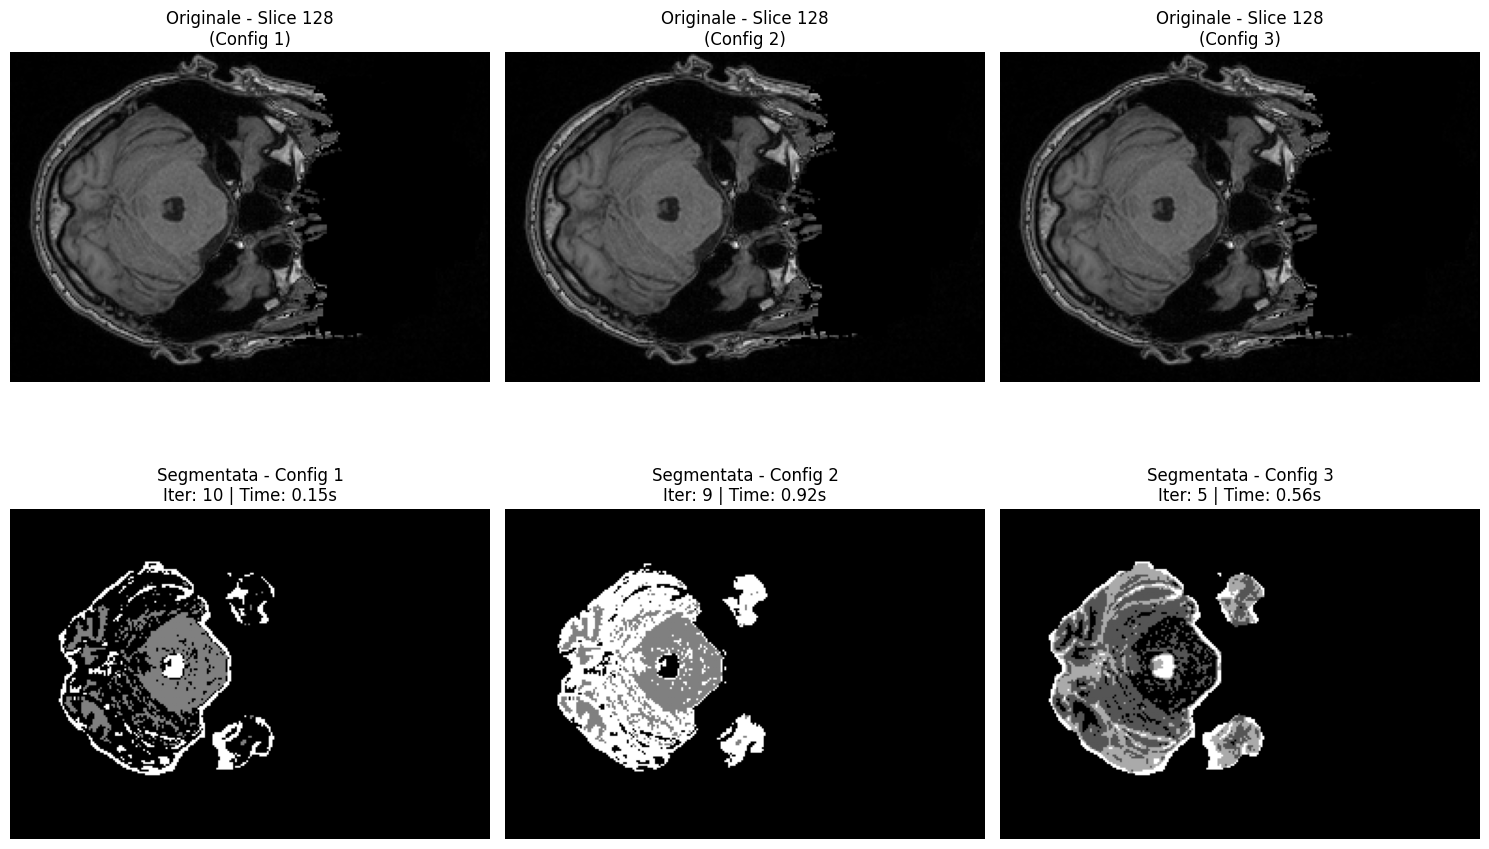

,config_id,n_clusters,init,algorithm,time_sec,n_iter,inertia,n_features,pixels_per_label
0,1,3,k-means++,lloyd,0.154,10,2.120982e+09,1,"{0: 650881, 1: 642433, 2: 221737}"
1,2,3,random,elkan,0.918,9,2.120982e+09,1,"{0: 221737, 1: 642433, 2: 650881}"
2,3,4,k-means++,lloyd,0.561,5,1.285953e+09,1,"{0: 534405, 1: 566800, 2: 262224, 3: 151622}"


In [4]:
# 1) Vectorize the data structure
t1_brain_vect = t1_dict['data'][bool_mask]
t1_brain_vect = t1_brain_vect.reshape(t1_brain_vect.shape[0],-1) # for the correct shape (n_samples x n_features)

configs = [
    {'n_clusters': 3, 'init': 'k-means++', 'n_init': 'auto', 'max_iter': 300, 'algorithm': 'lloyd', 'random_state': 42},
    {'n_clusters': 3, 'init': 'random', 'n_init': 10, 'max_iter': 300, 'algorithm': 'elkan', 'random_state': 42},
    {'n_clusters': 4, 'init': 'k-means++', 'n_init': 5, 'max_iter': 100, 'algorithm': 'lloyd', 'random_state': 42}
]

results_kmeans, kmeans_slices = kMeansSegmentation(t1_dict['data'], t1_brain_vect, bool_mask, configs, axis=2)
display(results_kmeans)

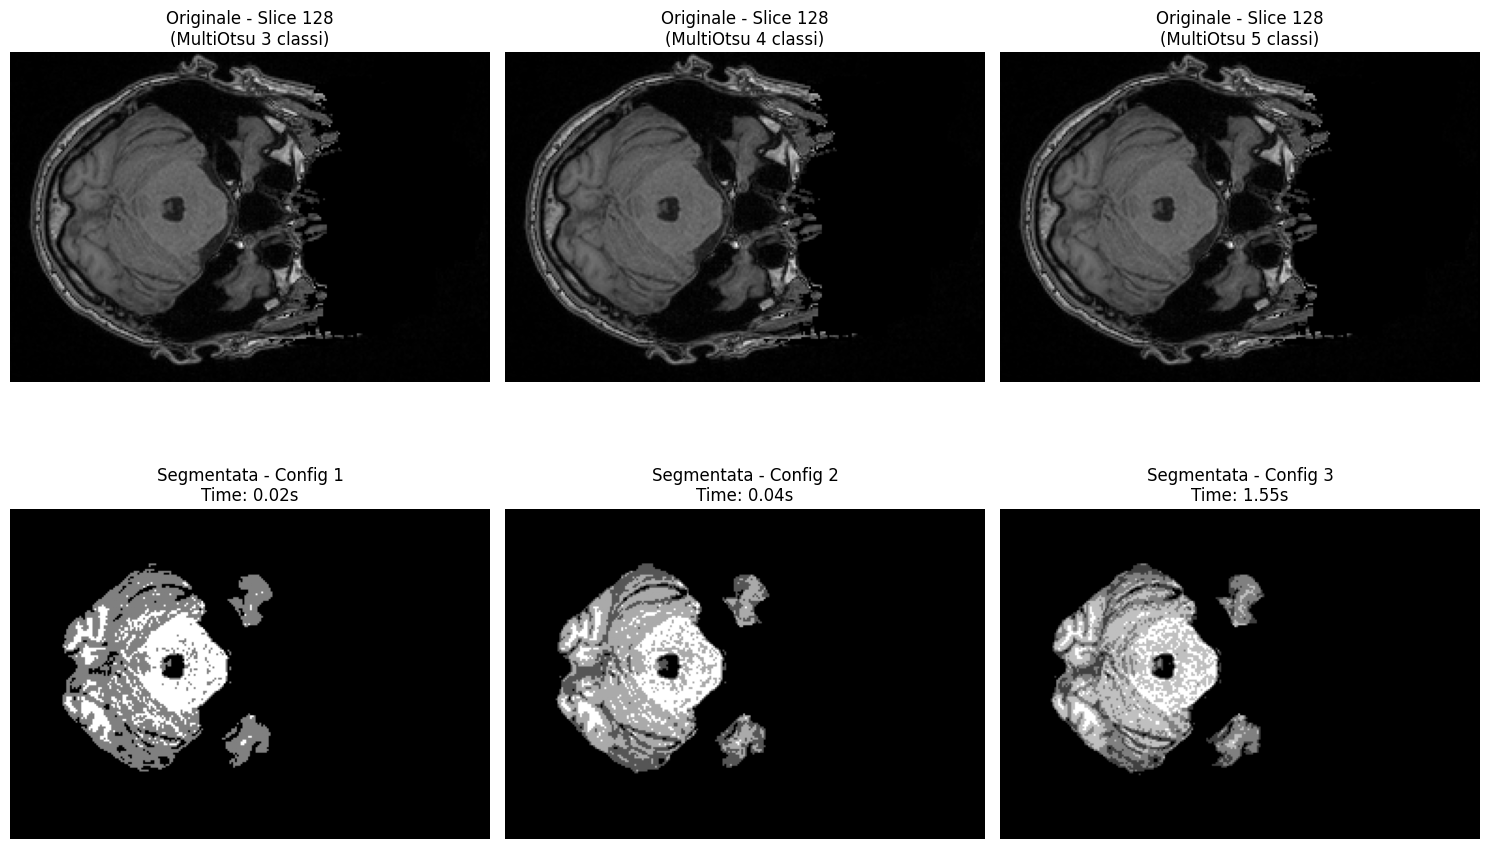

,config_id,classes,time_sec,thresholds,pixels_per_label
0,1,3,0.019,"[251.65, 385.39]","{0: 219859, 1: 646187, 2: 649005}"
1,2,4,0.043,"[205.89, 315.0, 402.99]","{0: 147575, 1: 247629, 2: 573918, 3: 545929}"
2,3,5,1.552,"[181.26, 279.8, 353.71, 417.06]","{0: 116338, 1: 163776, 2: 355642, 3: 419236, 4..."


In [5]:
configs_otsu = [
    {'classes': 3},  # Prova a separare in 3 tessuti (es. background, CSF/GM, WM)
    {'classes': 4},  # Prova a separare in 4 tessuti (es. background, CSF, GM, WM)
    {'classes': 5}   # Over-segmentazione giusto per vedere che succede
]

t1_brain_vect = t1_dict['data'][bool_mask]

results_otsu, otsu_slices = otsuSegmentation(t1_dict['data'], t1_brain_vect, bool_mask, configs_otsu, axis=2)
display(results_otsu)

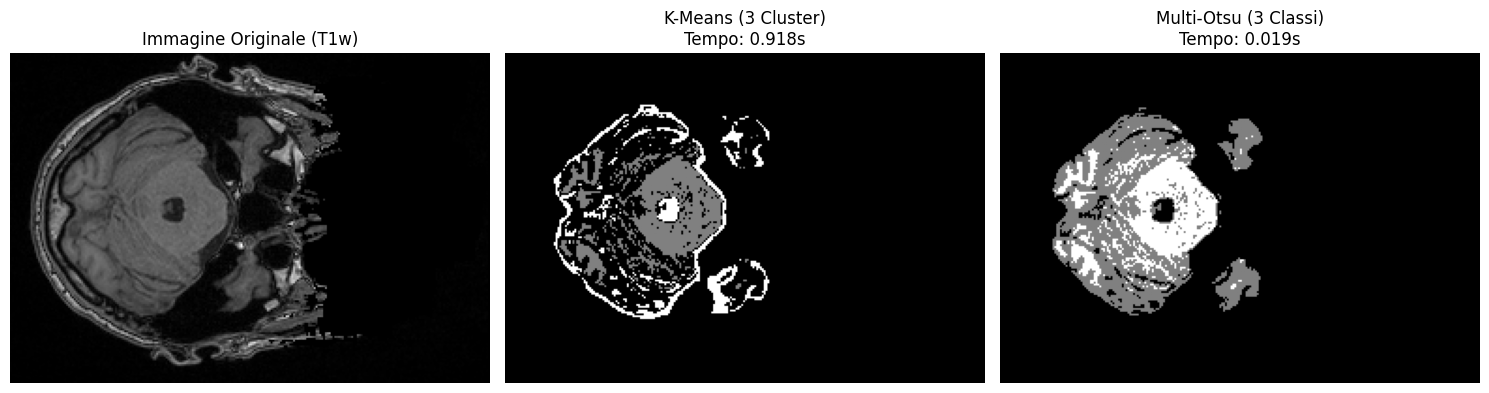

,config_id,n_clusters,init,algorithm,time_sec,n_iter,inertia,n_features,pixels_per_label,classes,thresholds
K-Means,2,3.0,random,elkan,0.918,9.0,2.120982e+09,1.0,"{0: 221737, 1: 642433, 2: 650881}",NaN,NaN
Multi-Otsu,1,NaN,NaN,NaN,0.019,NaN,NaN,NaN,"{0: 219859, 1: 646187, 2: 649005}",3.0,"[251.65, 385.39]"


In [6]:
kmeans_good_config = results_kmeans.iloc[1].to_dict()
otsu_good_config = results_otsu.iloc[0].to_dict()

total_results = compareSegmentationMethods(otsu_slices[0], kmeans_slices[1], otsu_slices[1], kmeans_good_config, otsu_good_config)
display(total_results)

## Low Pass Filtering - Edge Detection
These are the steps to implement
1) Select an axial slice (randomnly or givigin an index)
2) Transform the slice in the frequency domain with 2D Discrete Fourier Transform
3) Centering the frequencies
4) Extract the magnitude image
5) Implement low pass filters on this image: try butter worth, gaussian, step function...
6) Edge detection: try different methods (first derivative mask, second derivative, Canny, Sobel, Prewitt)

Before contrast stretching - Maximum value: 5087297.0
After contrast stretching - Maximum value: 15.442257402785012


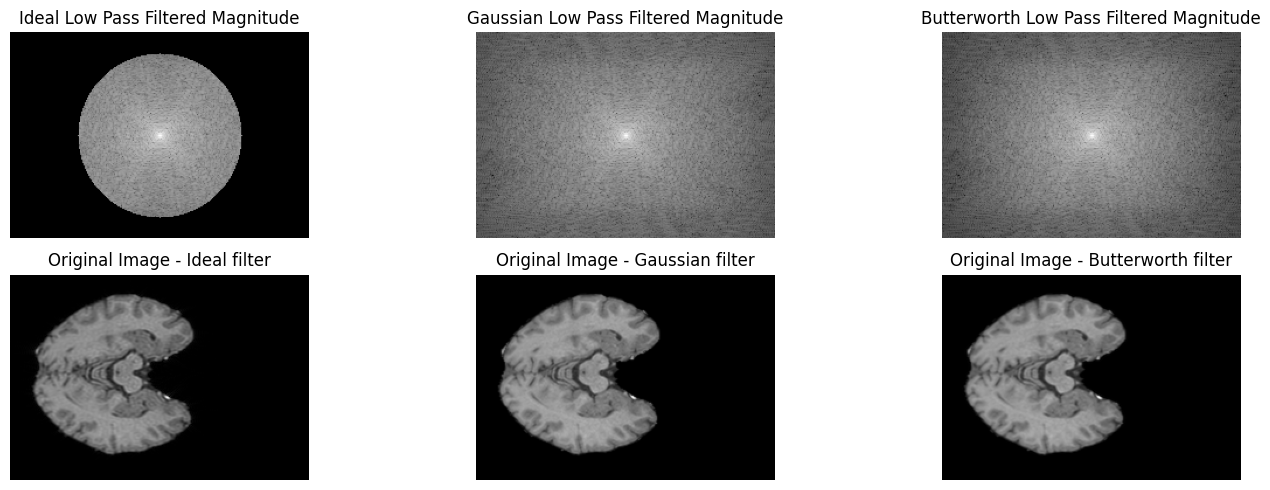

In [7]:
noisy_slice, _ = getSlice(t1_brain, slice_idx=150, axis='axial')
ideal_clean, gaussian_clean, butterw_clean = freqLowPassFilter(noisy_slice, 70)

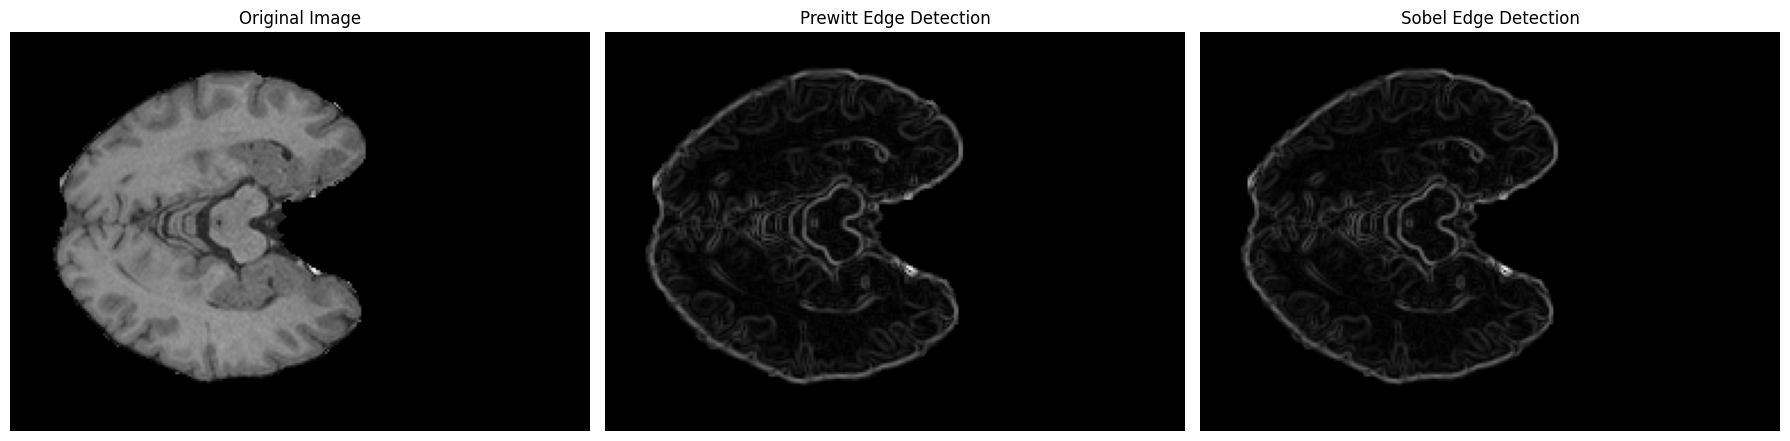

In [8]:
slice_prova, _ = getSlice(t1_brain, slice_idx=150)
prewitt_edges, sobel_edges = firstDerivativeEdgeDetection(slice_prova)

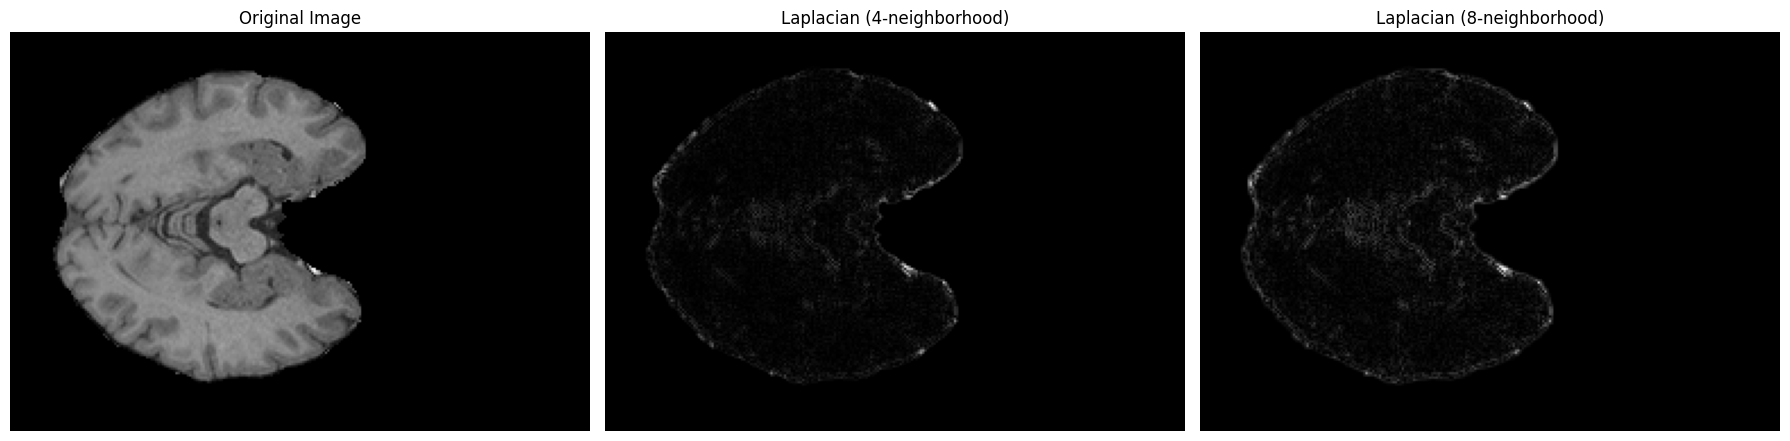

In [9]:
laplacian_45, laplacian_90 = secondDerivativeEdgeDetection(slice_prova)

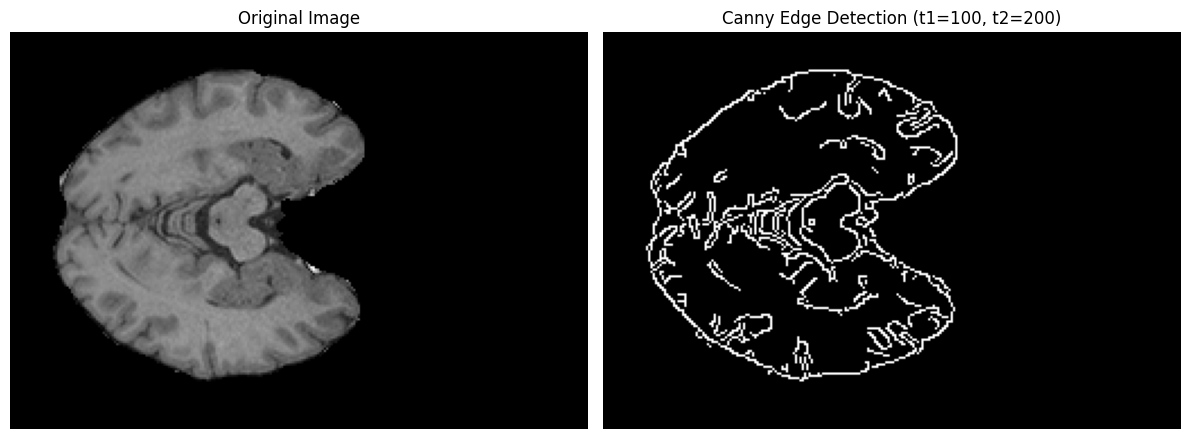

In [10]:
canny_edges = cannyEdgeDetection(slice_prova)

354.29743276255033 -918.021529260778
105.84762067763222 -153.1831606282222
42.201143814445004 -42.44021825758159


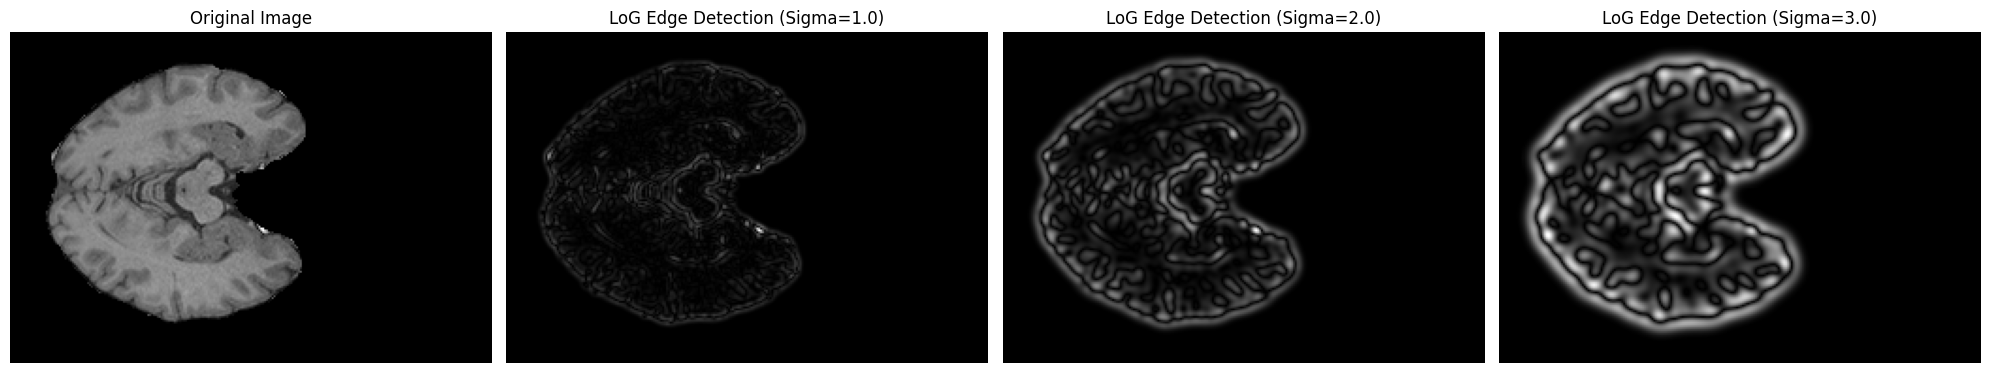

In [11]:
log_edges = logEdgeDetection(slice_prova)

## On fmri4d data apply gaussian smoothing on all the volumes to obtain fmri4d_smoothed

For this part I'm asked to perform gaussian smoothing not on 2d images but on 3d structures, so I cannot use cv.GaussianBlur that performs a blurring on 2D images --> looking on internet I see that scipy.ndimage.gaussian_filter performs a smoothing on n-dim images

In [12]:

fmri_smoothed = fmriVolumesSmoothing(fmri_dict['data'])
np.save('data/part1/fmri_smoothed.npy', fmri_smoothed)